# Survivorship-Corrected Aging Curves

The analysis code lives in the `mlb_aging` package, not in this notebook. Run
`uv sync --all-extras` once, then point this notebook's kernel at the project
venv. Feature engineering, model fitting, curve tracing and scoring are all
imported; what stays here is the narrative and the plots.

In [1]:
import matplotlib.pyplot as plt

from mlb_aging.dataset import build_training_frame, load_data
from mlb_aging.ipw import evaluate_retirement_model
from mlb_aging.metrics import METRICS, get_metric
from mlb_aging.pipeline import compare_ipw
from mlb_aging.plots import plot_curve_comparison

## Survivorship Bias Correction: Inverse Probability Weighting

In the standard dataset (`qual=100` PA), players who decline and lose playing time disappear
from the data before they are formally retired. This means the sample at older ages is
positively selected — only the better survivors remain — which understates the true rate
of decline.

**How IPW corrects for this:**
For each player-season we estimate the probability that the player continues to appear
in the dataset the following year (`p_survive`) using logistic regression on age, playing time,
and years of experience. Players who are unlikely to survive but are still observed receive a
higher inverse weight (`1 / p_survive`), compensating for the many similar players who
disappeared before them.

The final GAM sample weight is: `ipw_final_weight = base_weight (PA or G) * ipw_weight`

**Per-metric survival models:**
Each metric uses its own survival model that includes the player's lagged metric value (`perf_col`)
as an additional feature. This allows the model to distinguish players who play few games due to
declining skill from those who play few games for other reasons (e.g. defensive specialists with
low PA). Adding `perf_col` meaningfully improved the WAR survival model (AUC +0.028) but had
minimal effect on PA-weighted metrics (OPS, wRC+), where plate appearances already proxy
for hitting performance.

In [2]:
# Metric-agnostic baselines: age + playing time + experience, no lagged metric.
# Compare these against the per-metric AUCs in each section below.
base_train, _ = load_data(get_metric("wRC+"))
base_frame = build_training_frame(base_train, get_metric("wRC+"))

for weight_col, used_by in (("PA", "OPS, wRC+"), ("G", "Def, Spd, WAR")):
    diagnostics = evaluate_retirement_model(base_frame, weight_col=weight_col)
    print(f"=== Baseline {weight_col} retirement model ({used_by}) ===")
    print(diagnostics.summary())
    print()

=== Baseline PA retirement model (OPS, wRC+) ===
Hold-out seasons: 2014–2018  |  n=1827
  AUC-ROC:     0.8328   (0.5 = random, 1.0 = perfect)
  Brier score: 0.1275  (lower = better; naive baseline = 0.1638)

=== Baseline G retirement model (Def, Spd, WAR) ===
Hold-out seasons: 2014–2018  |  n=1827
  AUC-ROC:     0.7958   (0.5 = random, 1.0 = perfect)
  Brier score: 0.1394  (lower = better; naive baseline = 0.1638)



In [3]:
# Each metric is fitted twice -- uncorrected and IPW-weighted -- and both arms
# are scored identically, so the comparison is weighting-agnostic.
comparisons = {name: compare_ipw(spec) for name, spec in METRICS.items()}

## OPS Aging Curve

OPS  (fit weight PA)
  Survival AUC — without OPS_centralized_lag: 0.8328  |  with: 0.8329  (+0.0001)
  Peak age     — original: 26.0  |  IPW: 26.0
  Test MAE     — original: 0.0752  |  IPW: 0.0741  (+1.5%)

Mean survival probability by age (lower = stronger selection pressure):
Age
21    0.969
22    0.942
23    0.935
24    0.921
25    0.902
26    0.888
27    0.871
28    0.855
29    0.841
30    0.823
31    0.802
32    0.756
33    0.739
34    0.710
35    0.681
36    0.654
37    0.633
38    0.591
39    0.544
40    0.568


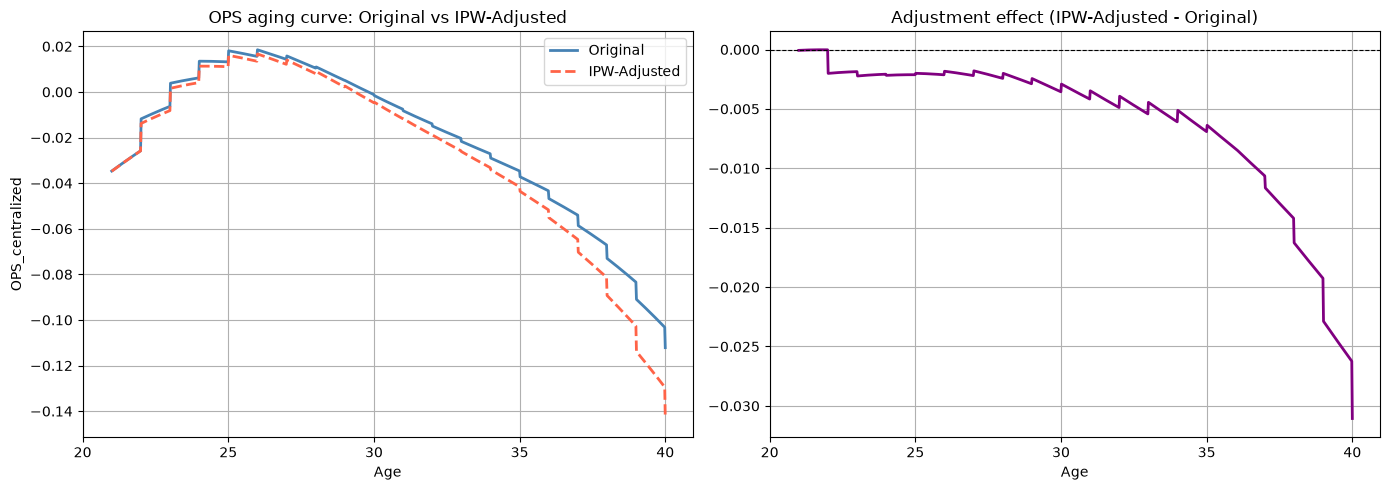

In [4]:
comparison = comparisons["OPS"]
print(comparison.summary())

print("\nMean survival probability by age (lower = stronger selection pressure):")
print(comparison.p_survive_by_age.round(3).to_string())

plot_curve_comparison(comparison.baseline.curve, comparison.corrected.curve,
                      comparison.spec)
plt.show()

The OPS survival model (AUC = 0.833) is the strongest of all five metrics, but adding
`OPS_centralized_lag` as a feature barely improved it over the baseline (AUC 0.8328 → 0.8329).
This is expected: for hitting metrics, plate appearances already encode performance quality —
a hitter who posts poor OPS quickly loses playing time, so PA captures the same signal.

The IPW adjustment reduced test MAE from 0.0752 to 0.0741 (≈1.5% improvement), with the
peak age unchanged at 26. The right panel shows where survivorship bias was largest: the
downward adjustment at ages 33+ indicates that the original curve overstated how well
older hitters maintain their OPS, because only above-average hitters retain 100+ PA at
those ages.

## wRC+ Aging Curve

wRC+  (fit weight PA)
  Survival AUC — without wRC+_lag: 0.8328  |  with: 0.8331  (+0.0002)
  Peak age     — original: 26.0  |  IPW: 26.0
  Test MAE     — original: 19.7154  |  IPW: 19.4684  (+1.3%)

Mean survival probability by age (lower = stronger selection pressure):
Age
21    0.970
22    0.942
23    0.935
24    0.921
25    0.902
26    0.888
27    0.871
28    0.855
29    0.841
30    0.823
31    0.802
32    0.756
33    0.739
34    0.710
35    0.681
36    0.654
37    0.633
38    0.591
39    0.543
40    0.569


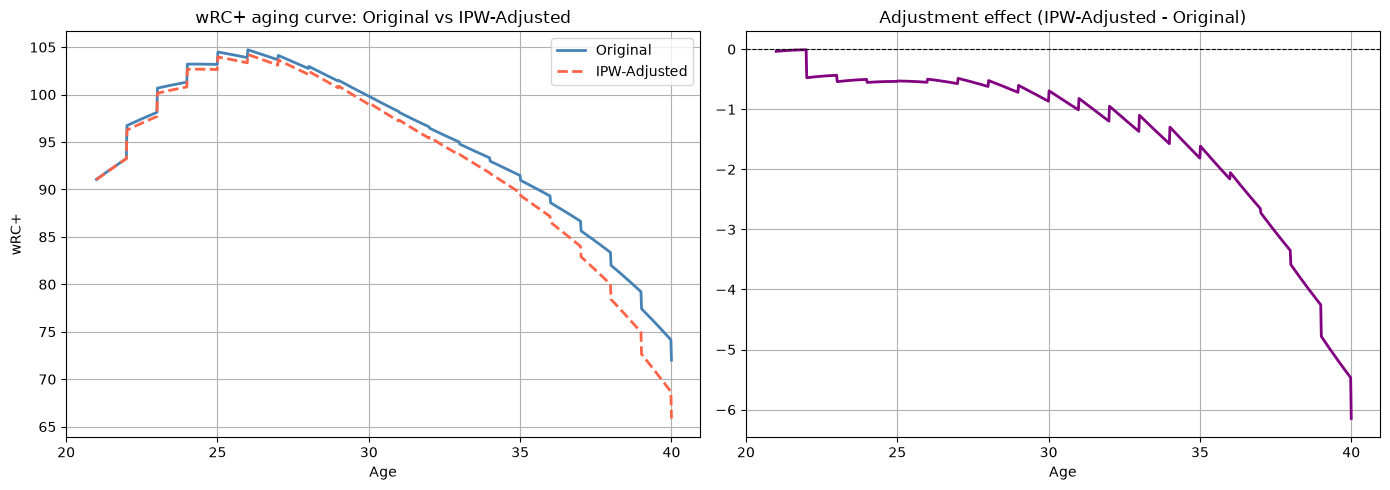

In [5]:
comparison = comparisons["wRC+"]
print(comparison.summary())

print("\nMean survival probability by age (lower = stronger selection pressure):")
print(comparison.p_survive_by_age.round(3).to_string())

plot_curve_comparison(comparison.baseline.curve, comparison.corrected.curve,
                      comparison.spec)
plt.show()

Like OPS, adding `wRC+_lag` to the survival model had negligible effect on discrimination
(AUC 0.8328 → 0.8331). PA remains the dominant predictor — the 100 PA threshold acts as
a natural performance filter, making explicit performance features redundant for the
survival model.

The IPW adjustment reduced test MAE from 19.72 to 19.47 (≈1.3% improvement), consistent
with OPS. The peak age of 26 is stable across both curves. The downward correction at
older ages reflects positive selection: the wRC+ 100+ PA pool above age 33 is
disproportionately composed of elite hitters, overstating how typical players age.

## Def Aging Curve

Def  (fit weight G)
  Survival AUC — without Def_lag: 0.7958  |  with: 0.8006  (+0.0048)
  Peak age     — original: 23.0  |  IPW: 23.0
  Test MAE     — original: 4.7541  |  IPW: 4.6579  (+2.0%)

Mean survival probability by age (lower = stronger selection pressure):
Age
21    0.954
22    0.925
23    0.919
24    0.905
25    0.892
26    0.879
27    0.866
28    0.852
29    0.838
30    0.817
31    0.800
32    0.755
33    0.740
34    0.711
35    0.686
36    0.659
37    0.633
38    0.588
39    0.535
40    0.553


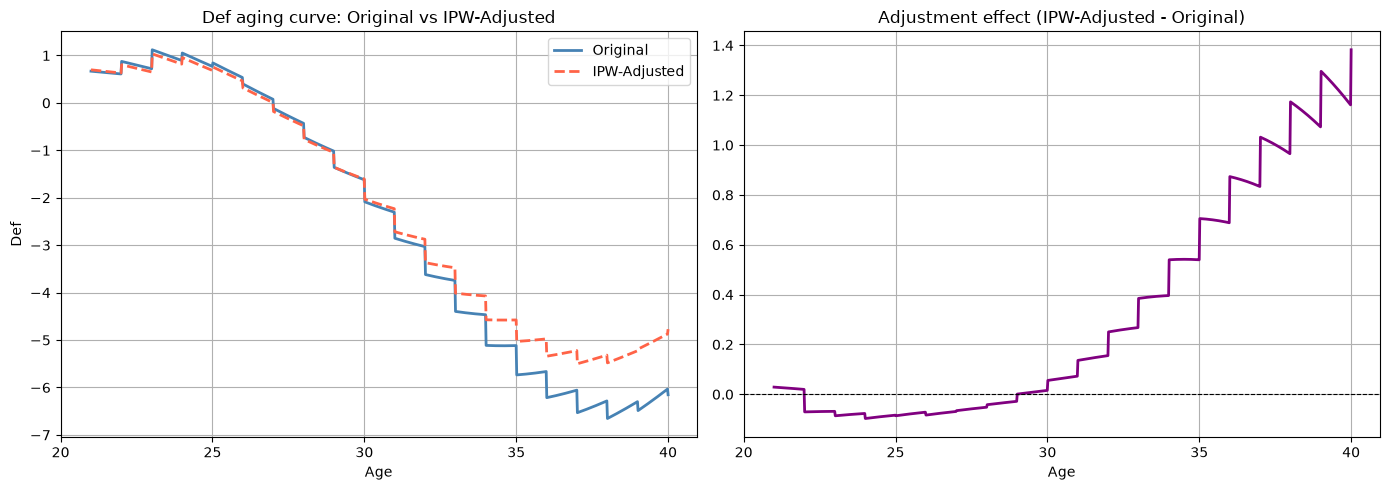

In [6]:
comparison = comparisons["Def"]
print(comparison.summary())

print("\nMean survival probability by age (lower = stronger selection pressure):")
print(comparison.p_survive_by_age.round(3).to_string())

plot_curve_comparison(comparison.baseline.curve, comparison.corrected.curve,
                      comparison.spec)
plt.show()

Defensive ability peaks early (around age 23), driven primarily by athleticism that
deteriorates gradually throughout a career.

The metric-agnostic G model (AUC = 0.796) struggled here because games played is an
ambiguous signal for Def: a player with low G could be a declining defender being phased
out, or a defensive specialist who rarely bats. Adding `Def_lag` helped the model
distinguish these cases (AUC → 0.801), slightly improving IPW weight quality and
reducing test MAE from 4.754 to 4.658 (≈2.0% improvement).

The improvement is modest, however, because logistic regression cannot fully disentangle
position-specific effects from true defensive decline with the available features. A more
granular model incorporating position would likely improve both the survival model and
the IPW correction.

## Spd Aging Curve

Spd  (fit weight G)
  Survival AUC — without Spd_lag: 0.7958  |  with: 0.7955  (-0.0002)
  Peak age     — original: 21.0  |  IPW: 21.0
  Test MAE     — original: 0.9862  |  IPW: 0.9813  (+0.5%)

Mean survival probability by age (lower = stronger selection pressure):
Age
21    0.953
22    0.928
23    0.921
24    0.908
25    0.893
26    0.880
27    0.867
28    0.852
29    0.836
30    0.815
31    0.799
32    0.753
33    0.739
34    0.710
35    0.685
36    0.658
37    0.632
38    0.592
39    0.539
40    0.565


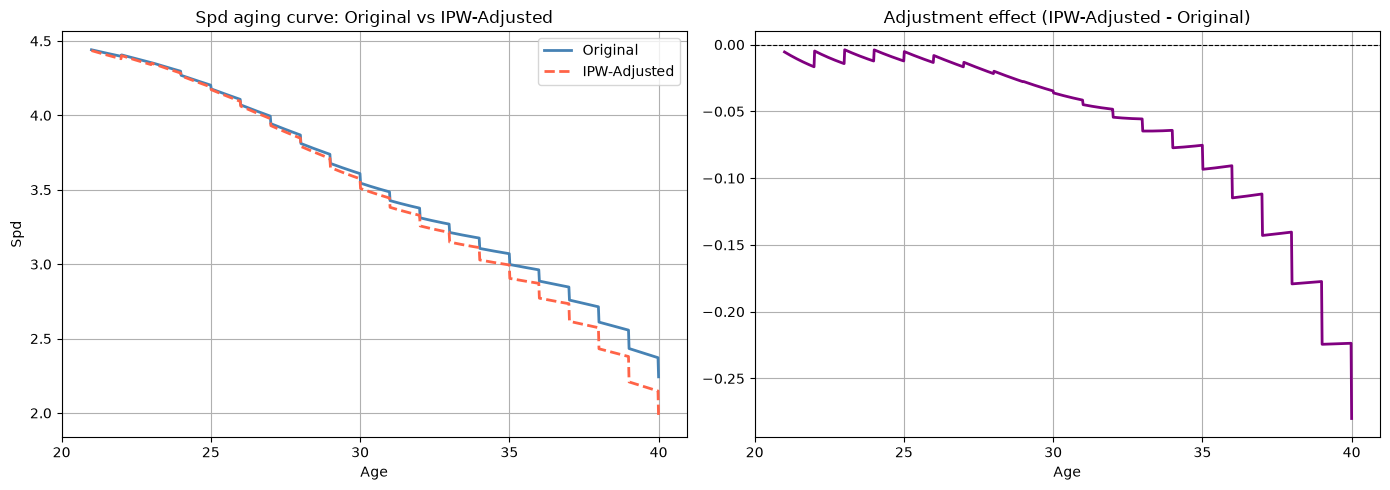

In [7]:
comparison = comparisons["Spd"]
print(comparison.summary())

print("\nMean survival probability by age (lower = stronger selection pressure):")
print(comparison.p_survive_by_age.round(3).to_string())

plot_curve_comparison(comparison.baseline.curve, comparison.corrected.curve,
                      comparison.spec)
plt.show()

Speed peaks earliest of all metrics (age 21) and declines monotonically throughout a career.

Adding `Spd_lag` to the survival model had no effect (AUC 0.7958 → 0.7955), slightly
worse than the baseline. This suggests that games played (G) already captures the speed
signal well: slow players lose roster spots quickly, so the selection mechanism is largely
driven by playing time rather than a direct speed threshold. Including the lag adds noise
without useful information beyond what G provides.

IPW reduced test MAE from 0.986 to 0.981 (≈0.5% improvement), the smallest gain across
all five metrics. Speed decline is steep and consistent enough that survivorship bias
has a relatively minor distorting effect on the estimated curve shape.

## WAR Aging Curve

WAR  (fit weight G)
  Survival AUC — without WAR_lag: 0.7958  |  with: 0.8233  (+0.0275)
  Peak age     — original: 25.0  |  IPW: 25.0
  Test MAE     — original: 1.4966  |  IPW: 1.4449  (+3.5%)

Mean survival probability by age (lower = stronger selection pressure):
Age
21    0.958
22    0.920
23    0.917
24    0.905
25    0.892
26    0.878
27    0.867
28    0.855
29    0.843
30    0.824
31    0.801
32    0.758
33    0.735
34    0.709
35    0.683
36    0.659
37    0.637
38    0.590
39    0.526
40    0.551


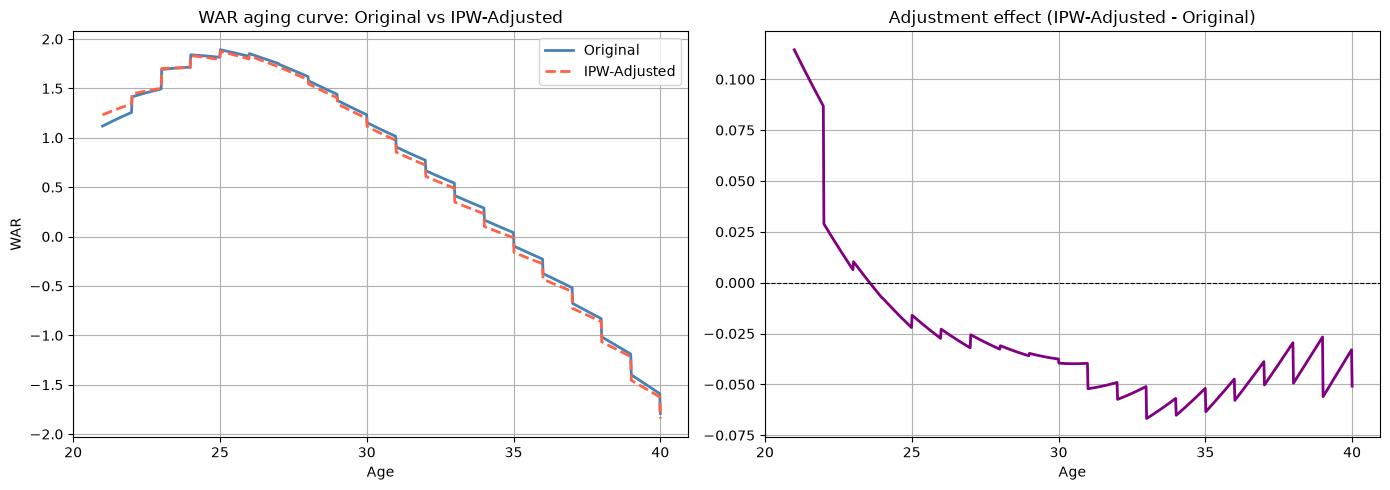

In [8]:
comparison = comparisons["WAR"]
print(comparison.summary())

print("\nMean survival probability by age (lower = stronger selection pressure):")
print(comparison.p_survive_by_age.round(3).to_string())

plot_curve_comparison(comparison.baseline.curve, comparison.corrected.curve,
                      comparison.spec)
plt.show()

WAR is a composite metric integrating hitting, defense, and baserunning, and it showed the
largest benefit from adding `perf_col` to the survival model (AUC 0.7958 → 0.8233,
+0.028 — the biggest improvement across all five metrics).

This makes intuitive sense: games played (G) alone is a poor proxy for overall value.
A player can log 130+ games as a below-replacement utility player, or miss games due to
injury while being genuinely valuable. The lagged WAR directly captures overall contribution,
giving the survival model a much stronger signal for identifying players at retirement risk.

IPW reduced test MAE from 1.497 to 1.445 (≈3.5% improvement), the largest absolute
reduction of all metrics. The corrected curve better captures the steep decline in overall
value after the peak at age 25, reflecting the compounding of physical decline across all
three components of WAR.